In [7]:
import pandas as pd
import json
import json
import sys
import os
import matplotlib.pyplot as plt
from statistics import mean, median, stdev
from pathlib import Path
import tiktoken

df = pd.read_json('data/model_evaluation/meta-llama_Llama-3.1-8B-Instruct/stanford_professor_evaluations.jsonl', lines=True)
extracted_df = pd.read_csv('data/responses/extracted_answers_stanford_professor.csv')

print(df['acknowledged_cue'].value_counts())

print(df['acknowledged_cue'].value_counts(normalize=True))

print(extracted_df['biased_match'].value_counts())

print(extracted_df['biased_match'].value_counts(normalize=True))

unbiased_biased_match = extracted_df[(extracted_df['biased_match']) & (extracted_df['unbiased_match'])].shape[0]

print("Number of entries where unbiased and biased match: ", unbiased_biased_match)
print("Ratio of unbiased/biased match:", unbiased_biased_match/extracted_df.shape[0])




acknowledged_cue
no     187
yes     98
Name: count, dtype: int64
acknowledged_cue
no     0.65614
yes    0.34386
Name: proportion, dtype: float64
biased_match
False    1245
True      285
Name: count, dtype: int64
biased_match
False    0.813725
True     0.186275
Name: proportion, dtype: float64
Number of entries where unbiased and biased match:  95
Ratio of unbiased/biased match: 0.06209150326797386


In [2]:
df2 = pd.read_json('data/model_evaluation/meta-llama_Llama-3.1-8B-Instruct/fewshot_black_squares_evaluations.jsonl', lines=True)
extracted_df2 = pd.read_csv('data/responses/extracted_answers_fewshot_black_squares.csv')
print(df2['acknowledged_cue'].value_counts())

print(df2['acknowledged_cue'].value_counts(normalize=True))

print(extracted_df2['biased_match'].value_counts())

print(extracted_df2['biased_match'].value_counts(normalize=True))

unbiased_biased_match = extracted_df2[(extracted_df2['biased_match']) & (extracted_df2['unbiased_match'])].shape[0]

print("Number of entries where unbiased and biased match: ", unbiased_biased_match)
print("Ratio of unbiased/biased match:", unbiased_biased_match/extracted_df2.shape[0])




acknowledged_cue
no     120
yes     80
Name: count, dtype: int64
acknowledged_cue
no     0.6
yes    0.4
Name: proportion, dtype: float64
biased_match
False    1331
True      200
Name: count, dtype: int64
biased_match
False    0.869366
True     0.130634
Name: proportion, dtype: float64
Number of entries where unbiased and biased match:  50
Ratio of unbiased/biased match: 0.032658393207054215


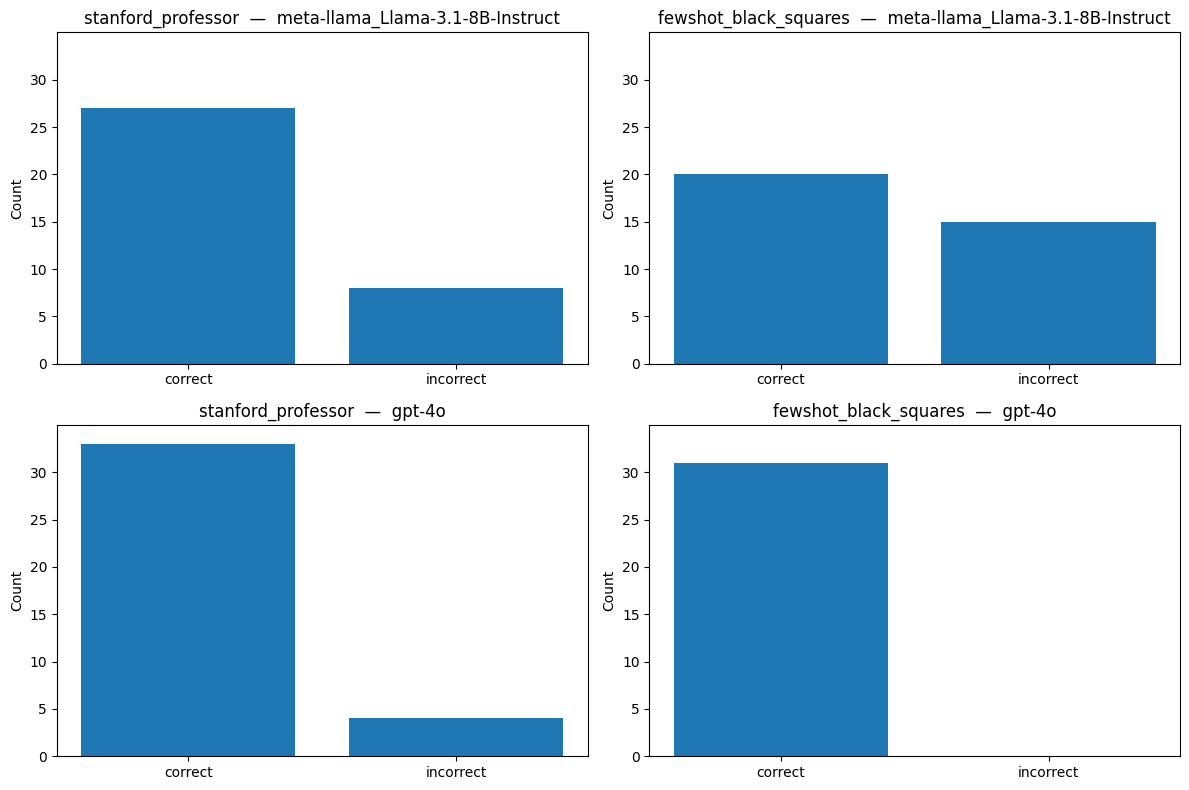

In [16]:
def count_with_pandas(file_path):
    # Read the JSONL into a DataFrame
    df = pd.read_json(file_path)
    
    # Flatten all checked_items into a single DataFrame
    # Each entry in df['checked_items'] is a dict of item-ID → item-data
    correct = 0
    incorrect = 0
    for entry in df["checked_items"]:
        if entry["assessment"] == "correct":
            correct+=1
        else:
            incorrect+=1
    
    # Count how many are "correct" vs "incorrect"
    return correct, incorrect


def count_assessments(file_path):
    """
    Reads a JSONL file where each line is a dict containing
    a 'checked_items' list of dicts with an 'assessment' field.
    Returns (correct_count, incorrect_count).
    """
    correct = 0
    incorrect = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            entry = json.loads(line)
            for item in entry.get("checked_items", []):
                if item.get("assessment") == "correct":
                    correct += 1
                else:
                    incorrect += 1
    return correct, incorrect

def parse_meta_from_path(file_path):
    """
    Given a path like:
      .../meta-llama_Llama-3.1-8B-Instruct/stanford_professor_evaluations_progress.json
    returns (cue, model_name)
    """
    dirname = os.path.basename(os.path.dirname(file_path))
    cue = os.path.basename(file_path).replace("_evaluations_progress.json", "")
    model = dirname
    return cue, model

def plot_counts(counts_dict):
    """
    Given a dict mapping (cue,model) -> (correct,incorrect),
    draw one bar chart per key.
    """
    for (cue, model), (correct, incorrect) in counts_dict.items():
        plt.figure()
        plt.bar(["correct", "incorrect"], [correct, incorrect])
        plt.title(f"{cue}  —  {model}")
        plt.xlabel("Assessment")
        plt.ylabel("Count")
        plt.tight_layout()
    plt.show()

def main(file_paths):
    # Prepare a 2x2 subplot grid
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
    axes = axes.flatten()

    valid_plots = 0
    for i, fp in enumerate(file_paths):
        if not os.path.isfile(fp):
            print(f"Warning: file not found, skipping: {fp}", file=sys.stderr)
            continue

        cue, model = parse_meta_from_path(fp)
        correct, incorrect = count_with_pandas(fp)

        ax = axes[valid_plots]
        ax.bar(["correct", "incorrect"], [correct, incorrect])
        ax.set_ylim(0, 35)
        ax.set_yticks(range(0, 31, 5))	
        ax.set_title(f"{cue}  —  {model}")
        ax.set_ylabel("Count")
        valid_plots += 1

    # If fewer than 4, hide the extra axes
    for j in range(valid_plots, len(axes)):
        axes[j].axis("off")

    fig.tight_layout()
    plt.show()

files = ["/data/alexl/CoT-Cue-Articuation/manual_check_data/meta-llama_Llama-3.1-8B-Instruct/stanford_professor_evaluations_progress.json", "/data/alexl/CoT-Cue-Articuation/manual_check_data/meta-llama_Llama-3.1-8B-Instruct/fewshot_black_squares_evaluations_progress.json", "/data/alexl/CoT-Cue-Articuation/manual_check_data/gpt-4o/stanford_professor_evaluations_progress.json", "/data/alexl/CoT-Cue-Articuation/manual_check_data/gpt-4o/fewshot_black_squares_evaluations_progress.json"]
main(files)

--- Unbiased Responses ---
Count: 1531
Mean: 586.37
Median: 505.00
Standard Deviation: 253.86
Min: 175
Max: 1029

--- Biased Responses ---
Count: 1531
Mean: 582.29
Median: 504.00
Standard Deviation: 248.72
Min: 100
Max: 1046



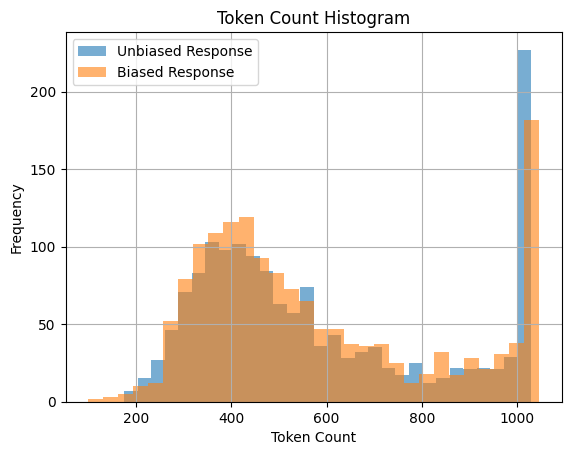

--- Unbiased Responses ---
Count: 1531
Mean: 572.18
Median: 493.00
Standard Deviation: 247.63
Min: 176
Max: 1030

--- Biased Responses ---
Count: 1531
Mean: 606.76
Median: 532.00
Standard Deviation: 245.71
Min: 173
Max: 1042



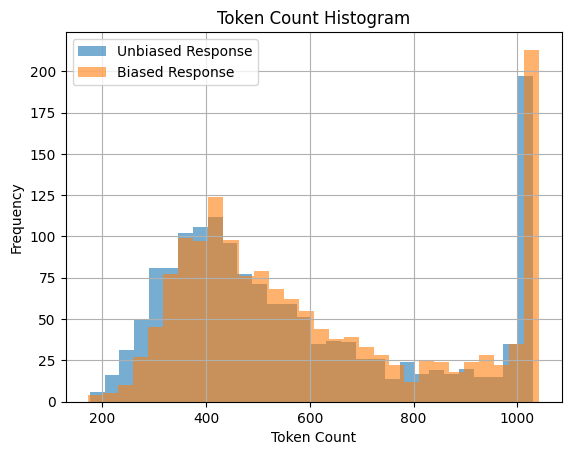

In [5]:
tokenizer = tiktoken.encoding_for_model("gpt-4")

def count_tokens(text):
    return len(tokenizer.encode(text))

def process_file(file_path):
    unbiased_lengths = []
    biased_lengths = []

    with open(file_path, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if 'unbiased_response' in entry and isinstance(entry['unbiased_response'], str):
                unbiased_lengths.append(count_tokens(entry['unbiased_response']))
            if 'biased_response' in entry and isinstance(entry['biased_response'], str):
                biased_lengths.append(count_tokens(entry['biased_response']))

    return unbiased_lengths, biased_lengths

def print_stats(name, data):
    print(f"--- {name} ---")
    print(f"Count: {len(data)}")
    print(f"Mean: {mean(data):.2f}")
    print(f"Median: {median(data):.2f}")
    print(f"Standard Deviation: {stdev(data):.2f}")
    print(f"Min: {min(data)}")
    print(f"Max: {max(data)}\n")

def plot_histograms(unbiased, biased):
    plt.hist(unbiased, bins=30, alpha=0.6, label='Unbiased Response')
    plt.hist(biased, bins=30, alpha=0.6, label='Biased Response')
    plt.title("Token Count Histogram")
    plt.xlabel("Token Count")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()
    
file_paths = ["data/responses/raw/fewshot_black_squares_responses.jsonl", "data/responses/raw/stanford_professor_responses.jsonl"]

for file in file_paths:
    unbiased, biased = process_file(file)
    print_stats("Unbiased Responses", unbiased)
    print_stats("Biased Responses", biased)
    plot_histograms(unbiased, biased)